In [216]:
# load dependencies
import pandas as pd
import os
import plotly.express as px
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go
import numpy as np
import requests
import io
from Resources.USDA_API import USDA_API_KEY

In [217]:
# Load Stats Can crops .csv file ("3210035901_databaseLoadingData.csv")
canada_crops_df = pd.read_csv('Resources/3210035901_databaseLoadingData.csv')
canada_crops_df.head()

,REF_DATE,GEO,DGUID,Harvest disposition,Type of crop,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1908,Canada,2021A000011124,Production (metric tonnes),Corn for grain,Metric tonnes,214,units,0,v114995731,1.19.11,580600.0,NaN,NaN,NaN,0
1,1909,Canada,2021A000011124,Production (metric tonnes),Corn for grain,Metric tonnes,214,units,0,v114995731,1.19.11,489600.0,NaN,NaN,NaN,0
2,1910,Canada,2021A000011124,Production (metric tonnes),Corn for grain,Metric tonnes,214,units,0,v114995731,1.19.11,363600.0,NaN,NaN,NaN,0
3,1911,Canada,2021A000011124,Production (metric tonnes),Corn for grain,Metric tonnes,214,units,0,v114995731,1.19.11,487400.0,NaN,NaN,NaN,0
4,1912,Canada,2021A000011124,Production (metric tonnes),Corn for grain,Metric tonnes,214,units,0,v114995731,1.19.11,430100.0,NaN,NaN,NaN,0


In [218]:
# Look at the shape of the df
canada_crops_df.shape

(708, 16)

In [219]:
# Look for Nan entries
canada_crops_df.isnull().sum()

REF_DATE                 0
GEO                      0
DGUID                    0
Harvest disposition      0
Type of crop             0
UOM                      0
UOM_ID                   0
SCALAR_FACTOR            0
SCALAR_ID                0
VECTOR                   0
COORDINATE               0
VALUE                  156
STATUS                 552
SYMBOL                 693
TERMINATED             708
DECIMALS                 0
dtype: int64

3 entire columns ("STATUS", "SYMBOL", "TERMINATED") are completely NaN.

In [220]:
# List columns
canada_crops_df.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Harvest disposition', 'Type of crop',
       'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE',
       'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='object')

In [221]:
# Check that it's all Canada stats (should be)
canada_crops_df['GEO'].unique()

array(['Canada'], dtype=object)

In [222]:
# Look at "DGUID" column
canada_crops_df['DGUID'].unique()

array(['2021A000011124'], dtype=object)

In [223]:
# Look at 'Harvest disposition' column
canada_crops_df['Harvest disposition'].unique()

array(['Production (metric tonnes)'], dtype=object)

In [224]:
# Look at 'Type of crop' column
canada_crops_df['Type of crop'].unique()

array(['Corn for grain', 'Lentils', 'Wheat, all', 'Wheat, durum',
       'Wheat, spring', 'Wheat, winter remaining'], dtype=object)

This project only requires "Corn for grain" and "Wheat, all".

In [225]:
# Drop all rows from 'Type of crop' except "Corn for grain" and "Wheat, all"
canada_crops_df = canada_crops_df[
    canada_crops_df['Type of crop'].isin(["Corn for grain", "Wheat, all"])
    ]
canada_crops_df["Type of crop"].unique()

array(['Corn for grain', 'Wheat, all'], dtype=object)

In [226]:
# Rename "Corn for grain" = "Corn" and "Wheat, all" = "Wheat"
canada_crops_df['Type of crop'] = canada_crops_df['Type of crop'].replace({
    "Corn for grain": "Corn",
    "Wheat, all": "Wheat"
})

canada_crops_df["Type of crop"].unique()

array(['Corn', 'Wheat'], dtype=object)

In [227]:
# Look at 'UOM' column
canada_crops_df["UOM"].unique()

array(['Metric tonnes'], dtype=object)

All data will be listed in Metric tonnes. This column could be eliminated and Metric tonnes can be listed in "Value" column.

In [228]:
canada_crops_df.head()

,REF_DATE,GEO,DGUID,Harvest disposition,Type of crop,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1908,Canada,2021A000011124,Production (metric tonnes),Corn,Metric tonnes,214,units,0,v114995731,1.19.11,580600.0,NaN,NaN,NaN,0
1,1909,Canada,2021A000011124,Production (metric tonnes),Corn,Metric tonnes,214,units,0,v114995731,1.19.11,489600.0,NaN,NaN,NaN,0
2,1910,Canada,2021A000011124,Production (metric tonnes),Corn,Metric tonnes,214,units,0,v114995731,1.19.11,363600.0,NaN,NaN,NaN,0
3,1911,Canada,2021A000011124,Production (metric tonnes),Corn,Metric tonnes,214,units,0,v114995731,1.19.11,487400.0,NaN,NaN,NaN,0
4,1912,Canada,2021A000011124,Production (metric tonnes),Corn,Metric tonnes,214,units,0,v114995731,1.19.11,430100.0,NaN,NaN,NaN,0


In [229]:
# Drop columns
canada_crops_df = canada_crops_df[["REF_DATE", "GEO", "Type of crop", "VALUE"]]
canada_crops_df.head()

,REF_DATE,GEO,Type of crop,VALUE
0,1908,Canada,Corn,580600.0
1,1909,Canada,Corn,489600.0
2,1910,Canada,Corn,363600.0
3,1911,Canada,Corn,487400.0
4,1912,Canada,Corn,430100.0


In [230]:
# Rename columns
canada_crops_df = canada_crops_df.rename(columns={
    "REF_DATE": "Year",
    "GEO": "Country",
    "Type of crop": "Crop",
    "VALUE": "Yield (Mt)"

})

canada_crops_df.head()

,Year,Country,Crop,Yield (Mt)
0,1908,Canada,Corn,580600.0
1,1909,Canada,Corn,489600.0
2,1910,Canada,Corn,363600.0
3,1911,Canada,Corn,487400.0
4,1912,Canada,Corn,430100.0


In [231]:
# See tail canada_crops_df
canada_crops_df.tail()

,Year,Country,Crop,Yield (Mt)
349,2021,Canada,Wheat,22422100.0
350,2022,Canada,Wheat,34878782.0
351,2023,Canada,Wheat,33413600.0
352,2024,Canada,Wheat,35938839.0
353,2025,Canada,Wheat,35547752.0


The CO2 dataset ends at the year 2023, there are two extra years in this data. We'll need to remove those years.

In [232]:
# Remove years after 2023
pre_canada_crops_df = canada_crops_df[canada_crops_df['Year'] <= 2023]

pre_canada_crops_df.tail()

,Year,Country,Crop,Yield (Mt)
347,2019,Canada,Wheat,32669800.0
348,2020,Canada,Wheat,35437200.0
349,2021,Canada,Wheat,22422100.0
350,2022,Canada,Wheat,34878782.0
351,2023,Canada,Wheat,33413600.0


In [233]:
# Organize data by year
pre_canada_crops_df = pre_canada_crops_df.groupby(["Year", "Country", "Crop"], as_index=False)["Yield (Mt)"].sum()


In [234]:
# View dataset
pre_canada_crops_df.head()

,Year,Country,Crop,Yield (Mt)
0,1908,Canada,Corn,580600.0
1,1908,Canada,Wheat,3060250.0
2,1909,Canada,Corn,489600.0
3,1909,Canada,Wheat,4537850.0
4,1910,Canada,Corn,363600.0


In [235]:
# Line plot yeild data
fig = px.line(
    pre_canada_crops_df,
    x="Year",
    y="Yield (Mt)",
    color="Crop", 
    title="Corn and Wheat Yields in Canada by Year",
    labels={"Yield (Mt)": "Crop Yield in Metric Tonnes (Mt)", "Year": "Year"}
)

fig.show()

In [236]:
# Line plot with linear regression
fig = go.Figure()

for crop in pre_canada_crops_df['Crop'].unique():
    df_crop = pre_canada_crops_df[pre_canada_crops_df['Crop'] == crop]
    X = df_crop['Year'].values.reshape(-1, 1)
    y = df_crop['Yield (Mt)'].values
    
    # Add the actual yield line
    fig.add_trace(go.Scatter(
        x=df_crop['Year'],
        y=y,
        mode='lines',
        name=f'{crop} Yield'
    ))
    
    # Fit and add regression line
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    fig.add_trace(go.Scatter(
        x=df_crop['Year'],
        y=y_pred,
        mode='lines',
        name=f'{crop} Linear Regression',
        line=dict(dash='dash') 
    ))

# Update layout
fig.update_layout(
    title='Corn and Wheat Yields in Canada per Year',
    xaxis_title='Year',
    yaxis_title='Crop Yield in Metric Tonnes (Mt)'
)

fig.show()

Plotting crop yields over time has shown us steady increase in yields over time. This will likely not be because of one solitary reason like precipitaion, gdp, CO2, etc. but, it likely a combination of many factors including the global market. The OWID CO2 dataset has a GDP column which could help perhaps show correlations between nation growth and crop yields. Precipiation might show correlations with peaks and valleys (interestingly the preciptiation did increase slightly over time as well). CO2 levels increased as well.

Let's bring in the USDA data now.

In [237]:
# Access USDA API querying wheat
url = (
    "https://quickstats.nass.usda.gov/api/api_GET/"
    "?key=" + USDA_API_KEY +
    "&source_desc=SURVEY"
    "&sector_desc=CROPS"
    "&commodity_desc=WHEAT"
    "&statisticcat_desc=YIELD"
    "&agg_level_desc=STATE"
    "&year__GE=1908"
    "&format=CSV"
)

In [238]:
# Call the API
response = requests.get(url)
response.raise_for_status()

In [239]:
# Load response into a DataFrame
USDA_wheat_df = pd.read_csv(io.StringIO(response.text))

In [240]:
USDA_wheat_df.head()

,source_desc,sector_desc,group_desc,commodity_desc,class_desc,prodn_practice_desc,util_practice_desc,statisticcat_desc,unit_desc,short_desc,...,location_desc,year,freq_desc,begin_code,end_code,reference_period_desc,week_ending,load_time,Value,CV (%)
0,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2024,ANNUAL,0,0,YEAR,NaN,2024-09-30 12:00:00.000,71.0,NaN
1,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2023,ANNUAL,0,0,YEAR,NaN,2024-09-30 12:00:00.000,75.0,NaN
2,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2022,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,72.0,NaN
3,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2021,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,83.0,NaN
4,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2020,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,72.0,NaN


In [241]:
# Try saving to .csv
USDA_wheat_df.to_csv('Resources/USDA_wheat.csv')

In [242]:
# Check file size in storage
file_path = "Resources/USDA_wheat.csv"
size_bytes = os.path.getsize(file_path)
size_mb = size_bytes / (1024*1024)

print(f"File size: {size_bytes} bytes ({size_mb:.2f} MB)")


File size: 9629729 bytes (9.18 MB)


The API key used to access this USDA Stats should not be publicly available. Instead save the file as a CSV to be accessed later.

In [243]:
# Access USDA API querying corn
url = (
    "https://quickstats.nass.usda.gov/api/api_GET/"
    "?key=" + USDA_API_KEY +
    "&source_desc=SURVEY"
    "&sector_desc=CROPS"
    "&commodity_desc=CORN"
    "&statisticcat_desc=YIELD"
    "&agg_level_desc=STATE"
    "&year__GE=1908"
    "&format=CSV"
)

In [244]:
# Call the API
response = requests.get(url)
response.raise_for_status()

In [245]:
# Load response into a DataFrame
USDA_corn_df = pd.read_csv(io.StringIO(response.text))

In [246]:
# View corn_df
USDA_corn_df.head()

,source_desc,sector_desc,group_desc,commodity_desc,class_desc,prodn_practice_desc,util_practice_desc,statisticcat_desc,unit_desc,short_desc,...,location_desc,year,freq_desc,begin_code,end_code,reference_period_desc,week_ending,load_time,Value,CV (%)
0,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2025,ANNUAL,0,0,YEAR,NaN,2025-08-12 12:00:00.000,157.8,NaN
1,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2025,ANNUAL,0,0,YEAR - AUG FORECAST,NaN,2025-08-12 12:00:00.000,157.8,NaN
2,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2024,ANNUAL,0,0,YEAR,NaN,2025-01-10 12:00:00.000,0.0,NaN
3,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2024,ANNUAL,0,0,YEAR - AUG FORECAST,NaN,2024-08-12 12:00:00.000,160.5,NaN
4,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2024,ANNUAL,0,0,YEAR - NOV FORECAST,NaN,2024-11-08 12:00:00.000,159.9,NaN


In [247]:
# Try saving to .csv
USDA_corn_df.to_csv('Resources/USDA_corn.csv')

In [248]:
# Check file size in storage
file_path = "Resources/USDA_corn.csv"
size_bytes = os.path.getsize(file_path)
size_mb = size_bytes / (1024*1024)

print(f"File size: {size_bytes} bytes ({size_mb:.2f} MB)")

File size: 5329072 bytes (5.08 MB)


Saved two separate CSV files, one for wheat and one for corn. Load both from Resources folder if needed, see commented out snippet below. 

In [249]:
# Load USDA wheat data ('USDA_wheat.csv')
# USDA_wheat_df = pd.read_csv('Resources/USDA_wheat.csv')

# Load USDA cord data ('USDA_corn.csv')
# USDA_corn_df = pd.read_csv('Resources/USDA_corn.csv')


In [250]:
# View cord df
USDA_corn_df.head()

,source_desc,sector_desc,group_desc,commodity_desc,class_desc,prodn_practice_desc,util_practice_desc,statisticcat_desc,unit_desc,short_desc,...,location_desc,year,freq_desc,begin_code,end_code,reference_period_desc,week_ending,load_time,Value,CV (%)
0,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2025,ANNUAL,0,0,YEAR,NaN,2025-08-12 12:00:00.000,157.8,NaN
1,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2025,ANNUAL,0,0,YEAR - AUG FORECAST,NaN,2025-08-12 12:00:00.000,157.8,NaN
2,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2024,ANNUAL,0,0,YEAR,NaN,2025-01-10 12:00:00.000,0.0,NaN
3,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2024,ANNUAL,0,0,YEAR - AUG FORECAST,NaN,2024-08-12 12:00:00.000,160.5,NaN
4,SURVEY,CROPS,FIELD CROPS,CORN,ALL CLASSES,ALL PRODUCTION PRACTICES,GRAIN,YIELD,BU / ACRE,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",...,OTHER STATES,2024,ANNUAL,0,0,YEAR - NOV FORECAST,NaN,2024-11-08 12:00:00.000,159.9,NaN


In [251]:
# View wheat df
USDA_wheat_df.head()

,source_desc,sector_desc,group_desc,commodity_desc,class_desc,prodn_practice_desc,util_practice_desc,statisticcat_desc,unit_desc,short_desc,...,location_desc,year,freq_desc,begin_code,end_code,reference_period_desc,week_ending,load_time,Value,CV (%)
0,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2024,ANNUAL,0,0,YEAR,NaN,2024-09-30 12:00:00.000,71.0,NaN
1,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2023,ANNUAL,0,0,YEAR,NaN,2024-09-30 12:00:00.000,75.0,NaN
2,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2022,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,72.0,NaN
3,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2021,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,83.0,NaN
4,SURVEY,CROPS,FIELD CROPS,WHEAT,ALL CLASSES,ALL PRODUCTION PRACTICES,ALL UTILIZATION PRACTICES,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",...,ALABAMA,2020,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,72.0,NaN


The format of both these df's will be very similar. Verify the data, eliminiate unnecessary columnsm change column names, concat the two dfs.

In [252]:
# Verify unique entries in USDA_wheat_df['commodity_desc'] column
USDA_wheat_df['commodity_desc'].unique()

array(['WHEAT'], dtype=object)

In [253]:
# Look at columns in USDA_wheat_df
USDA_wheat_df.columns

Index(['source_desc', 'sector_desc', 'group_desc', 'commodity_desc',
       'class_desc', 'prodn_practice_desc', 'util_practice_desc',
       'statisticcat_desc', 'unit_desc', 'short_desc', 'domain_desc',
       'domaincat_desc', 'agg_level_desc', 'state_ansi', 'state_fips_code',
       'state_alpha', 'state_name', 'asd_code', 'asd_desc', 'county_ansi',
       'county_code', 'county_name', 'region_desc', 'zip_5', 'watershed_code',
       'watershed_desc', 'congr_district_code', 'country_code', 'country_name',
       'location_desc', 'year', 'freq_desc', 'begin_code', 'end_code',
       'reference_period_desc', 'week_ending', 'load_time', 'Value', 'CV (%)'],
      dtype='object')

In [254]:
# Let's drop some columns in increments for usability
USDA_wheat_df = USDA_wheat_df.drop(columns=['source_desc', 'sector_desc', 'group_desc', 'class_desc', 'prodn_practice_desc', 'util_practice_desc'])
USDA_wheat_df.head()

,commodity_desc,statisticcat_desc,unit_desc,short_desc,domain_desc,domaincat_desc,agg_level_desc,state_ansi,state_fips_code,state_alpha,...,location_desc,year,freq_desc,begin_code,end_code,reference_period_desc,week_ending,load_time,Value,CV (%)
0,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,STATE,1.0,1,AL,...,ALABAMA,2024,ANNUAL,0,0,YEAR,NaN,2024-09-30 12:00:00.000,71.0,NaN
1,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,STATE,1.0,1,AL,...,ALABAMA,2023,ANNUAL,0,0,YEAR,NaN,2024-09-30 12:00:00.000,75.0,NaN
2,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,STATE,1.0,1,AL,...,ALABAMA,2022,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,72.0,NaN
3,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,STATE,1.0,1,AL,...,ALABAMA,2021,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,83.0,NaN
4,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,STATE,1.0,1,AL,...,ALABAMA,2020,ANNUAL,0,0,YEAR,NaN,2024-01-09 15:00:00.000,72.0,NaN


In [255]:
# Check domain_desc column
USDA_wheat_df['domain_desc'].unique()

array(['TOTAL'], dtype=object)

In [256]:
# Check domaincat_desc
USDA_wheat_df['domaincat_desc'].unique()

array(['NOT SPECIFIED'], dtype=object)

In [257]:
# Check agg_level_desc
USDA_wheat_df['agg_level_desc'].unique()

array(['STATE'], dtype=object)

In [258]:
# Check state_ansi
USDA_wheat_df['state_ansi'].unique()

array([ 1.,  4.,  5.,  6.,  8., 10., 12., 13., 16., 17., 18., 19., 20.,
       21., 22., 23., 24., 26., 27., 28., 29., 30., 31., 32., 34., 35.,
       36., 37., 38., 39., 40., 41., 42., 45., 46., 47., 48., 49., 50.,
       51., 53., 54., 55., 56., nan])

In [259]:
# Check reference_period_desc
USDA_wheat_df['reference_period_desc'].unique()

array(['YEAR', 'YEAR - AUG FORECAST', 'YEAR - JUL FORECAST',
       'YEAR - SEP FORECAST', 'YEAR - JUN FORECAST',
       'YEAR - MAY FORECAST'], dtype=object)

In [260]:
# Check freq_desc
USDA_wheat_df['freq_desc'].unique()

array(['ANNUAL'], dtype=object)

This is a tedious slow process of checking each column. Let's try a different approach.

In [261]:
# Check all the unique entries for each column at once
unique_counts = USDA_wheat_df.nunique()
unique_counts

commodity_desc              1
statisticcat_desc           1
unit_desc                   3
short_desc                 46
domain_desc                 1
domaincat_desc              1
agg_level_desc              1
state_ansi                 44
state_fips_code            45
state_alpha                45
state_name                 45
asd_code                    0
asd_desc                    0
county_ansi                 0
county_code                 0
county_name                 0
region_desc                 0
zip_5                       0
watershed_code              1
watershed_desc              0
congr_district_code         0
country_code                1
country_name                1
location_desc              45
year                      118
freq_desc                   1
begin_code                  1
end_code                    1
reference_period_desc       6
week_ending                 0
load_time                  82
Value                    1039
CV (%)                      0
dtype: int

In [262]:
# Check USDA shape
USDA_wheat_df.shape

(30599, 33)

In [263]:
# Drop some columns with 1 or 0 unique entries
USDA_wheat_df = USDA_wheat_df.drop(columns=['domain_desc', 'domaincat_desc', 'agg_level_desc', 'asd_code', 'asd_desc',
                                            'county_ansi', 'county_code', 'county_name', 'region_desc', 'zip_5', 'watershed_code',
                                            'watershed_desc', 'congr_district_code', 'week_ending', 'CV (%)', 'state_ansi', 'state_fips_code',
                                            'state_alpha', 'country_code'])

USDA_wheat_df.head()

,commodity_desc,statisticcat_desc,unit_desc,short_desc,state_name,country_name,location_desc,year,freq_desc,begin_code,end_code,reference_period_desc,load_time,Value
0,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2024,ANNUAL,0,0,YEAR,2024-09-30 12:00:00.000,71.0
1,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2023,ANNUAL,0,0,YEAR,2024-09-30 12:00:00.000,75.0
2,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2022,ANNUAL,0,0,YEAR,2024-01-09 15:00:00.000,72.0
3,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2021,ANNUAL,0,0,YEAR,2024-01-09 15:00:00.000,83.0
4,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2020,ANNUAL,0,0,YEAR,2024-01-09 15:00:00.000,72.0


This slow systematic approach is helping to eliminate some unnecessary columns and also ensure integrity by not removing too much.

In [264]:
# Drop a few more columns after review
USDA_wheat_df= USDA_wheat_df.drop(columns=['begin_code', 'end_code', 'load_time'])
USDA_wheat_df.head()

,commodity_desc,statisticcat_desc,unit_desc,short_desc,state_name,country_name,location_desc,year,freq_desc,reference_period_desc,Value
0,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2024,ANNUAL,YEAR,71.0
1,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2023,ANNUAL,YEAR,75.0
2,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2022,ANNUAL,YEAR,72.0
3,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2021,ANNUAL,YEAR,83.0
4,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2020,ANNUAL,YEAR,72.0


The DataFrame is starting to look a lot more manageable. I need to know more about the 'reference_period_desc' column (reference period description). There are six unique entries for this. I need to know if they still translate to an annual amount. The 'freq_desc' column seems to suggest that it is still only an annual account but, a little subject matter research should be done here.

API source outlining column definitions: https://quickstats.nass.usda.gov/api

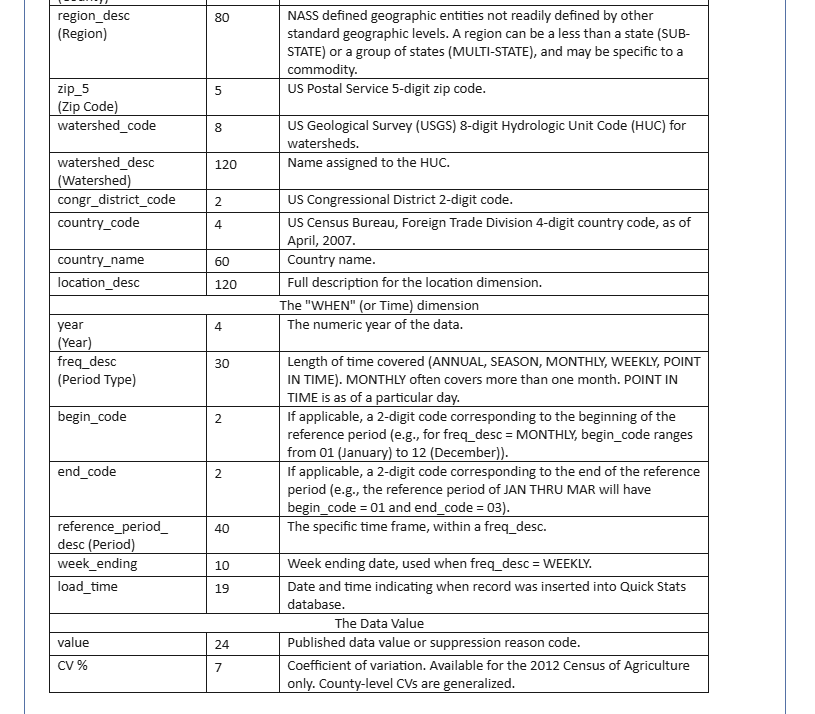

In [265]:
# Review reference period column
USDA_wheat_df['reference_period_desc'].unique()

array(['YEAR', 'YEAR - AUG FORECAST', 'YEAR - JUL FORECAST',
       'YEAR - SEP FORECAST', 'YEAR - JUN FORECAST',
       'YEAR - MAY FORECAST'], dtype=object)

In [266]:
# Review state_name column
USDA_wheat_df['state_name'].unique()

array(['ALABAMA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA', 'COLORADO',
       'DELAWARE', 'FLORIDA', 'GEORGIA', 'IDAHO', 'ILLINOIS', 'INDIANA',
       'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA', 'MAINE', 'MARYLAND',
       'MICHIGAN', 'MINNESOTA', 'MISSISSIPPI', 'MISSOURI', 'MONTANA',
       'NEBRASKA', 'NEVADA', 'NEW JERSEY', 'NEW MEXICO', 'NEW YORK',
       'NORTH CAROLINA', 'NORTH DAKOTA', 'OHIO', 'OKLAHOMA', 'OREGON',
       'PENNSYLVANIA', 'SOUTH CAROLINA', 'SOUTH DAKOTA', 'TENNESSEE',
       'TEXAS', 'UTAH', 'VERMONT', 'VIRGINIA', 'WASHINGTON',
       'WEST VIRGINIA', 'WISCONSIN', 'WYOMING', 'OTHER STATES'],
      dtype=object)

As long as there's only one entry per state per year it should be OK. I also assumed the data would be for the entire USA, not per state. Let's pick one year and one state and see how many entries there are.

In [267]:
# Test number of entries
USDA_wheat_2020 = USDA_wheat_df[USDA_wheat_df["year"] == 2020]
USDA_wheat_2020

,commodity_desc,statisticcat_desc,unit_desc,short_desc,state_name,country_name,location_desc,year,freq_desc,reference_period_desc,Value
4,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2020,ANNUAL,YEAR,72.0
139,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ARIZONA,UNITED STATES,ARIZONA,2020,ANNUAL,YEAR,99.0
274,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ARKANSAS,UNITED STATES,ARKANSAS,2020,ANNUAL,YEAR,55.0
409,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",CALIFORNIA,UNITED STATES,CALIFORNIA,2020,ANNUAL,YEAR,77.2
544,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",COLORADO,UNITED STATES,COLORADO,2020,ANNUAL,YEAR,27.0
...,...,...,...,...,...,...,...,...,...,...,...
25598,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR - AUG FORECAST,71.0
25599,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR - JUL FORECAST,70.0
25600,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR - JUN FORECAST,71.0
25601,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR - MAY FORECAST,70.0


In [268]:
# Try just Alabama
USDA_wheat_2020_AL = USDA_wheat_df[
    (USDA_wheat_df["year"] == 2020) & 
    (USDA_wheat_df["state_name"] == "ALABAMA")
]
USDA_wheat_2020_AL

,commodity_desc,statisticcat_desc,unit_desc,short_desc,state_name,country_name,location_desc,year,freq_desc,reference_period_desc,Value
4,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2020,ANNUAL,YEAR,72.0
17038,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2020,ANNUAL,YEAR,72.0


Ok a new issue, I assumed that the only column at risk was "reference_period_desc", but "short_desc" also seems to have some redundancy. That was almost an oversight.

In [269]:
# Try just Wisconsin
USDA_wheat_2020_WS = USDA_wheat_df[
    (USDA_wheat_df["year"] == 2020) & 
    (USDA_wheat_df["state_name"] == "WISCONSIN")
]

USDA_wheat_2020_WS

,commodity_desc,statisticcat_desc,unit_desc,short_desc,state_name,country_name,location_desc,year,freq_desc,reference_period_desc,Value
5544,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR,69.0
25597,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR,69.0
25598,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR - AUG FORECAST,71.0
25599,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR - JUL FORECAST,70.0
25600,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR - JUN FORECAST,71.0
25601,WHEAT,YIELD,BU / ACRE,"WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR - MAY FORECAST,70.0


"short_desc" is a short description of previous columns, a concatenation of several columns. Maybe reducing this field to a single unique entry will eliminate redundancy.

Again from: https://quickstats.nass.usda.gov/param_define

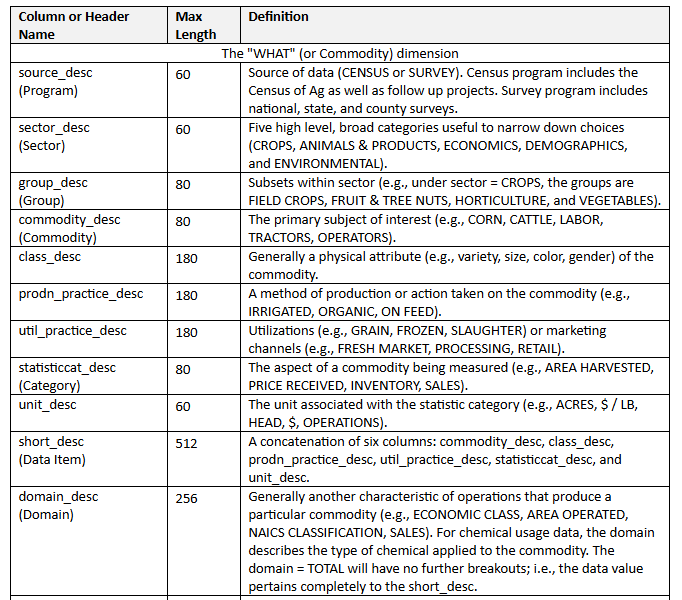

In [270]:
# Check out "short_desc" column
USDA_wheat_df['short_desc'].nunique()

46

In [271]:
# Check out "short_desc" column
USDA_wheat_df['short_desc'].unique()

array(['WHEAT - YIELD, MEASURED IN BU / ACRE',
       'WHEAT - YIELD, MEASURED IN BU / NET PLANTED ACRE',
       'WHEAT - YIELD, MEASURED IN BU / PLANTED ACRE',
       'WHEAT, IRRIGATED - YIELD, MEASURED IN BU / ACRE',
       'WHEAT, IRRIGATED - YIELD, MEASURED IN BU / NET PLANTED ACRE',
       'WHEAT, IRRIGATED - YIELD, MEASURED IN BU / PLANTED ACRE',
       'WHEAT, NON-IRRIGATED - YIELD, MEASURED IN BU / ACRE',
       'WHEAT, NON-IRRIGATED - YIELD, MEASURED IN BU / NET PLANTED ACRE',
       'WHEAT, NON-IRRIGATED - YIELD, MEASURED IN BU / PLANTED ACRE',
       'WHEAT, NON-IRRIGATED, CONTINUOUS CROP - YIELD, MEASURED IN BU / ACRE',
       'WHEAT, NON-IRRIGATED, CONTINUOUS CROP - YIELD, MEASURED IN BU / NET PLANTED ACRE',
       'WHEAT, NON-IRRIGATED, FOLLOWING SUMMER FALLOW - YIELD, MEASURED IN BU / ACRE',
       'WHEAT, NON-IRRIGATED, FOLLOWING SUMMER FALLOW - YIELD, MEASURED IN BU / NET PLANTED ACRE',
       'WHEAT, SPRING, (EXCL DURUM) - YIELD, MEASURED IN BU / ACRE',
       'WHEAT,

Let's try taking only 'WHEAT - YIELD, MEASURED IN BU / ACRE' rows from the 'short_desc' column.

In [272]:
# Eliminate all but 'WHEAT - YIELD, MEASURED IN BU / ACRE' rows 
USDA_wheat_df = USDA_wheat_df[USDA_wheat_df['short_desc'] == 'WHEAT - YIELD, MEASURED IN BU / ACRE']

USDA_wheat_df.shape

(5810, 11)

We've dropped 24,789 of rows (see image below of row 48 from this script):

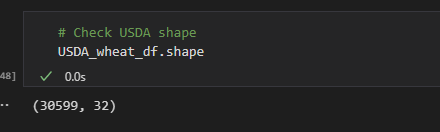

In [273]:
# Try just Wisconsin
USDA_wheat_2020_WS = USDA_wheat_df[
    (USDA_wheat_df["year"] == 2020) & 
    (USDA_wheat_df["state_name"] == "WISCONSIN")
]

USDA_wheat_2020_WS

,commodity_desc,statisticcat_desc,unit_desc,short_desc,state_name,country_name,location_desc,year,freq_desc,reference_period_desc,Value
5544,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",WISCONSIN,UNITED STATES,WISCONSIN,2020,ANNUAL,YEAR,69.0


In [274]:
# Check out "short_desc" column
print(USDA_wheat_df['short_desc'].unique())
print(USDA_wheat_df['short_desc'].nunique())

['WHEAT - YIELD, MEASURED IN BU / ACRE']
1


Now let's check "reference_period_desc" which was our previous concern.

In [275]:
# Check "reference_period_desc" column
print(USDA_wheat_df['reference_period_desc'].unique())
print(USDA_wheat_df['reference_period_desc'].nunique())

['YEAR' 'YEAR - AUG FORECAST' 'YEAR - JUL FORECAST' 'YEAR - SEP FORECAST']
4


Let's look for states with more than one row per year.

In [276]:
# Groupby state and year and count duplicates
dupes = (
    USDA_wheat_df
    .groupby(["state_name", "year"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

dupes


,state_name,year,count
82,ALABAMA,1990,4
83,ALABAMA,1991,2
84,ALABAMA,1992,2
85,ALABAMA,1993,2
86,ALABAMA,1994,2
...,...,...,...
4801,WYOMING,1996,2
4802,WYOMING,1997,2
4803,WYOMING,1998,4
4804,WYOMING,1999,4


Ok, we still have issues here. Let's do something similar with "reference_period_desc" as "short_desc".

In [277]:
# Eliminate all but 'WHEAT - YIELD, MEASURED IN BU / ACRE' rows 
USDA_wheat_df = USDA_wheat_df[USDA_wheat_df['reference_period_desc'] == 'YEAR']

USDA_wheat_df.shape

(4830, 11)

Now we've lost 980 rows. Let's check for duplicates once more.

In [278]:
# Groupby state and year and count duplicates
dupes = (
    USDA_wheat_df
    .groupby(["state_name", "year"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

dupes

,state_name,year,count


OK! Now we should have only 1 row per state, a simplified DataFrame with less redundancy.

In [279]:
USDA_wheat_df.head()

,commodity_desc,statisticcat_desc,unit_desc,short_desc,state_name,country_name,location_desc,year,freq_desc,reference_period_desc,Value
0,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2024,ANNUAL,YEAR,71.0
1,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2023,ANNUAL,YEAR,75.0
2,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2022,ANNUAL,YEAR,72.0
3,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2021,ANNUAL,YEAR,83.0
4,WHEAT,YIELD,BU / ACRE,"WHEAT - YIELD, MEASURED IN BU / ACRE",ALABAMA,UNITED STATES,ALABAMA,2020,ANNUAL,YEAR,72.0


Still to do:

- natioanl sum per year (only one entry per year, a sum of all states)
- some sort of unit conversion from BU / ACRE to metric tons (not sure how)
- rename some headings / final clean for usability
- edit pipleline and do same for corn df
- concat for dfs
- visuals

OK - major issue I should have noticed immediately: unit conversion

- BU / ACRE is pretty meaningless without ACREAGE, of which there is none
- Attempt to download another file

OK! Found a new file (Resources/USDA-CORN_WHEAT_PROD.csv)

In [280]:
# Load New USDA File
USDA_corn_wheat_df = pd.read_csv('Resources/USDA-CORN_WHEAT_PROD.csv')
USDA_corn_wheat_df.head()

,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,...,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Value,CV (%)
0,SURVEY,2025,YEAR,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"16,741,644,000",NaN
1,SURVEY,2025,YEAR,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,WHEAT,"WHEAT - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"1,927,026,000",NaN
2,SURVEY,2024,YEAR,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"14,866,744,000",NaN
3,SURVEY,2024,YEAR,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,WHEAT,"WHEAT - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"1,971,301,000",NaN
4,SURVEY,2023,YEAR,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"15,340,520,000",NaN


The above df still needs work but, it looks like it has an absolute value (measured in BU or bushel) instead of a ratio. A bushel doesn't have an exact weight, but that can be calculated.

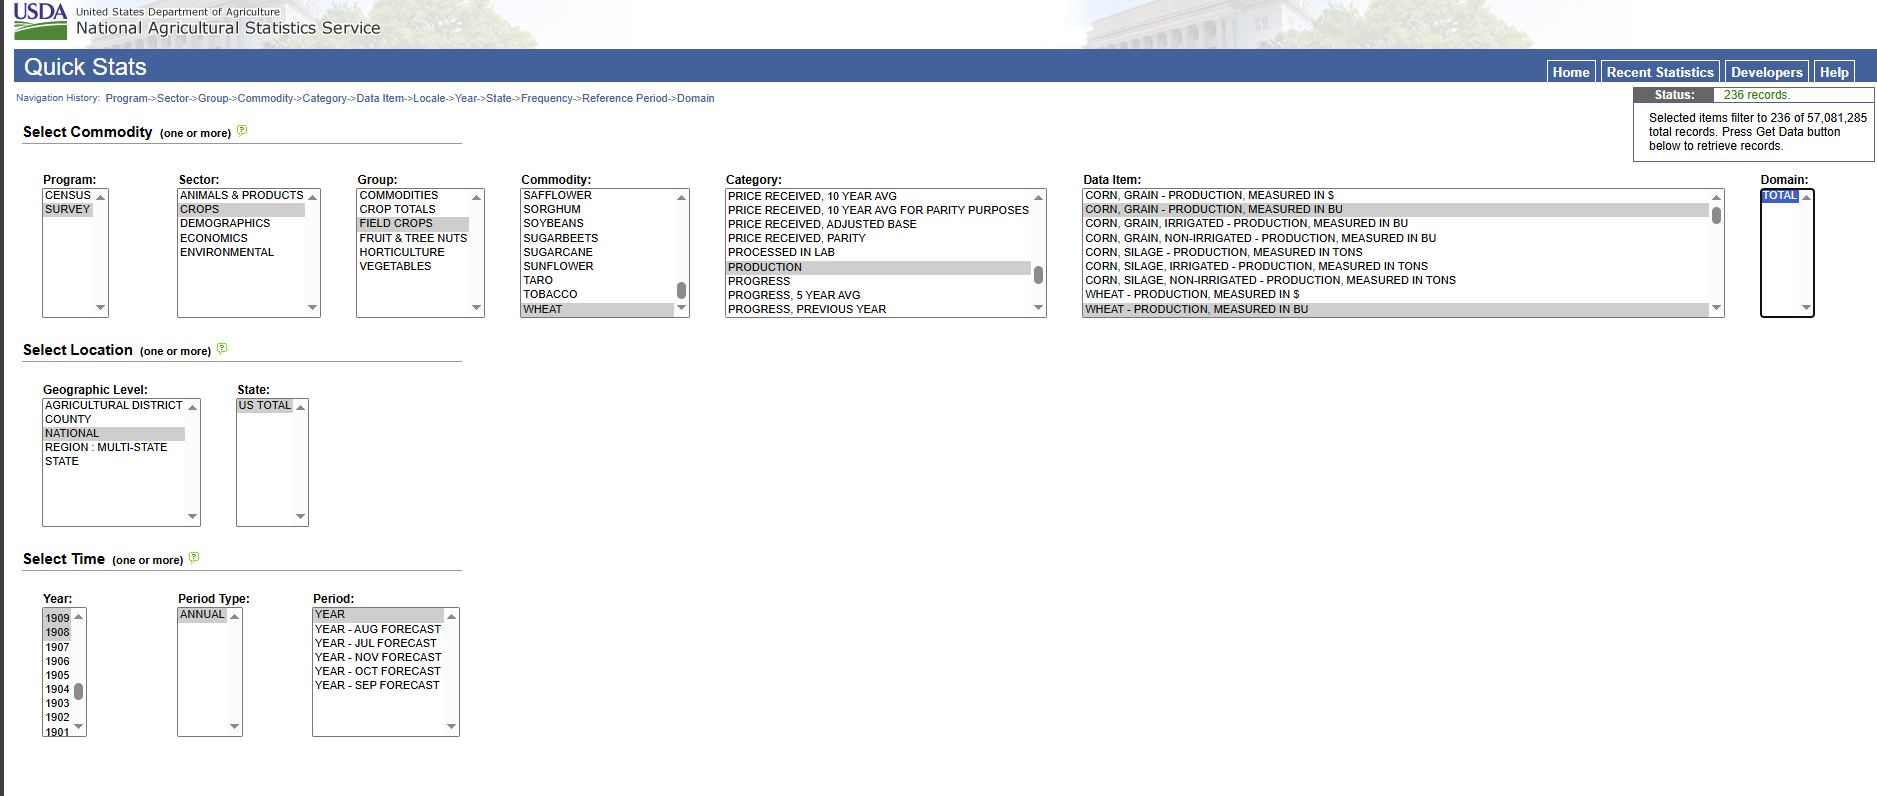

In [281]:
# Look at these columns to see what's necessary and what's redundant
unique_counts = USDA_corn_wheat_df.nunique()
unique_counts

Program               1
Year                118
Period                1
Week Ending           0
Geo Level             1
State                 1
State ANSI            0
Ag District           0
Ag District Code      0
County                0
County ANSI           0
Zip Code              0
Region                0
watershed_code        1
Watershed             0
Commodity             2
Data Item             2
Domain                1
Domain Category       1
Value               236
CV (%)                0
dtype: int64

In [282]:
# So let's clean up this new df
USDA_corn_wheat_df.columns

Index(['Program', 'Year', 'Period', 'Week Ending', 'Geo Level', 'State',
       'State ANSI', 'Ag District', 'Ag District Code', 'County',
       'County ANSI', 'Zip Code', 'Region', 'watershed_code', 'Watershed',
       'Commodity', 'Data Item', 'Domain', 'Domain Category', 'Value',
       'CV (%)'],
      dtype='object')

We can elminate the "Data Item" column if we simply make note that the unit of measure is production measured in BU (bushels).

In [283]:
# Keep only the necessary columns
USDA_corn_wheat_df= USDA_corn_wheat_df[['Year', 'State', 'Commodity','Value']]
USDA_corn_wheat_df.head()

,Year,State,Commodity,Value
0,2025,US TOTAL,CORN,"16,741,644,000"
1,2025,US TOTAL,WHEAT,"1,927,026,000"
2,2024,US TOTAL,CORN,"14,866,744,000"
3,2024,US TOTAL,WHEAT,"1,971,301,000"
4,2023,US TOTAL,CORN,"15,340,520,000"


In [284]:
# Rename columns
USDA_corn_wheat_df = USDA_corn_wheat_df.rename(columns={
    'State': 'Country',
    'Commodity': 'Crop',
    'Value': 'Production (BU)'
})

USDA_corn_wheat_df.head()

,Year,Country,Crop,Production (BU)
0,2025,US TOTAL,CORN,"16,741,644,000"
1,2025,US TOTAL,WHEAT,"1,927,026,000"
2,2024,US TOTAL,CORN,"14,866,744,000"
3,2024,US TOTAL,WHEAT,"1,971,301,000"
4,2023,US TOTAL,CORN,"15,340,520,000"


In [285]:
# Replace 'US TOTAL' with United States
USDA_corn_wheat_df['Country'] = USDA_corn_wheat_df['Country'].replace("US TOTAL", "United States")
USDA_corn_wheat_df.head()

,Year,Country,Crop,Production (BU)
0,2025,United States,CORN,"16,741,644,000"
1,2025,United States,WHEAT,"1,927,026,000"
2,2024,United States,CORN,"14,866,744,000"
3,2024,United States,WHEAT,"1,971,301,000"
4,2023,United States,CORN,"15,340,520,000"


In [286]:
# Replace ALL CAPS Crop rows
USDA_corn_wheat_df['Crop'] = USDA_corn_wheat_df['Crop'].replace({
    "CORN": "Corn",
    "WHEAT": "Wheat"
})

USDA_corn_wheat_df.head()

,Year,Country,Crop,Production (BU)
0,2025,United States,Corn,"16,741,644,000"
1,2025,United States,Wheat,"1,927,026,000"
2,2024,United States,Corn,"14,866,744,000"
3,2024,United States,Wheat,"1,971,301,000"
4,2023,United States,Corn,"15,340,520,000"
